# Hierarchical MCN-GNN: Superclass and Class Classification

Predicts chemical taxonomy at two levels simultaneously using:
- **MCN-augmented node features** (340-dim spectral + 4 community features)
- **Shared GAT encoder** with two classification heads
- **Hierarchical constraint** at inference: class logits masked by predicted superclass
- **JSON output** with top-k predictions and confidence probabilities

## 1. Imports

In [1]:
import os, csv
import json
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import random
from pyvis.network import Network
import matplotlib.colors as mcolors
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_edge
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print(f'networkx  : {nx.__version__}')
print(f'igraph    : {ig.__version__}')
print(f'leidenalg : {leidenalg.version}')

C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


networkx  : 3.4.2
igraph    : 1.0.0
leidenalg : 0.12.0


networkx  : 3.4.2
igraph    : 1.0.0
leidenalg : 0.12.0


networkx  : 3.4.2
igraph    : 1.0.0
leidenalg : 0.12.0


## 2. Configurations

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
# Paths 
mgf_path          = os.path.expanduser("NIST/NIST_GC_EI_MAX_LIBRARY.mgf")
nist_classes_path = "NIST/nist_classes.csv"
nist_dir          = "C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST"
masst_tsv_path    = f"{nist_dir}/results_t50_e20.tsv"

# Mode: full dataset or 4-class subset 
# Set use_4class = True to run on the 4-class subset
# Set use_4class = False to run on the full dataset (~193k spectra)
use_4class = True

four_classes = [
    "Benzene and substituted derivatives",
    "Carboxylic acids and derivatives",
    "Fatty Acyls",
    "Organooxygen compounds",
]

# Community detection settings
leiden_seed         = 42     # reproducibility
min_class_count     = 20     # for label encoding (used in community purity check)

# dataset split settings
random_state = 42
test_size    = 0.20
val_size     = 0.10

# Descriptive prefix for all saved artifacts (plots, CSVs, model checkpoints)
_masst_tag = os.path.splitext(os.path.basename(masst_tsv_path))[0].replace('results_', '')
RUN_TAG = f"hierarchical_{'4class' if use_4class else 'full'}_{_masst_tag}"

def artifact_path(stem, ext):
  """e.g. results/hierarchical_4class_t50_e20_model.pt"""
  return os.path.join(RESULTS_DIR, f"{RUN_TAG}_{stem}.{ext}")

print(f"Mode          : {'4-class subset' if use_4class else 'Full dataset'}")
print(f"MASST TSV     : {masst_tsv_path}")
print(f"TSV exists    : {os.path.exists(masst_tsv_path)}")
print(f"Leiden seed   : {leiden_seed}")
print(f"Run tag       : {RUN_TAG}")
print(f"Results dir   : {os.path.abspath(RESULTS_DIR)}")

Mode          : 4-class subset
MASST TSV     : C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST/results_t50_e20.tsv
TSV exists    : True
Leiden seed   : 42
Run tag       : hierarchical_4class_t50_e20
Results dir   : C:\Users\bibhushaojha\Desktop\graph-based-spectral-classifier\results


## 3. Data Loading

Load spectra + labels and build the train / val / test split. The split is defined here
so the training loss can later be masked to training nodes. The molecular network itself
is built over **all** nodes (transductive) purely from spectral similarity, so community
detection never uses labels — leakage-free.

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == "BEGIN IONS":  inside, meta, peaks = True, {}, []; continue
            if line == "END IONS":
                if inside:
                    entries.append({
                        "meta": meta.copy(),
                        "peaks": np.array(peaks, dtype=float) if peaks else np.empty((0,2), dtype=float),
                    })
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if "=" in line:
                k, v = line.split('=', 1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries


def read_nist_classes_csv(path):
    label_map = {}
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for row in csv.DictReader(f):
            sid = int(row["file"].strip())
            sk  = row["Superklass"].strip()
            k   = row["klass"].strip()
            sub = row["subklass"].strip()
            label_map[sid] = {
                "superclass": None if sk  == "null" else sk,
                "klass":      None if (k  == "null" or k.startswith("subklass:")) else k,
                "subclass":   None if sub == "null" else sub,
            }
    return label_map


def build_dataset(mgf_entries, label_map):
    dataset = []
    for e in mgf_entries:
        scans = e["meta"].get("SCANS", "").strip()
        if not scans: continue
        try: sid = int(scans)
        except ValueError: continue
        lbl = label_map.get(sid, {"superclass": None, "klass": None, "subclass": None})
        dataset.append({
            "scan_id":    sid,
            "peaks":      e["peaks"],
            "superclass": lbl["superclass"],
            "klass":      lbl["klass"],
            "subclass":   lbl["subclass"],
        })
    print(f'Dataset: {len(dataset):,} spectra')
    return dataset


In [4]:
print("Loading MGF ...")
mgf_entries = parse_mgf_file(mgf_path)
print(f"  {len(mgf_entries):,} entries")

print("Loading labels ...")
nist_label_map = read_nist_classes_csv(nist_classes_path)
print(f"  {len(nist_label_map):,} labeled")

# Build dataset (scan_id → peaks + labels)
dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'], 'superclass': lbl['superclass'], 'klass': lbl['klass']})

print(f'Spectra with both superclass + class labels: {len(dataset):,}')

# Superclass distribution before 4-class filter
superclass_counts = Counter(r['superclass'] for r in dataset)

print(f'\nUnique superclasses: {len(superclass_counts)}')
print('Superclass distribution:')
for sc, cnt in superclass_counts.most_common():
    print(f'  {cnt:7,}  {sc}')

klass_counts = Counter(r['klass'] for r in dataset)
print(f'\nUnique classes: {len(klass_counts)}')
print('Top 10 classes:')
for cls, cnt in klass_counts.most_common(10):
    print(f'  {cnt:7,}  {cls}')

# 4-class filter (only used when USE_4CLASS = True) 
if use_4class:
    dataset = [r for r in dataset if r['klass'] in four_classes]
    print(f'\nAfter 4-class filter: {len(dataset):,} spectra')

    print('\nClass distribution after 4-class filter:')
    for cls in four_classes:
        n = sum(1 for r in dataset if r['klass'] == cls)
        print(f'  {n:7,}  {cls}')

    # Superclass distribution after 4-class filter
    superclass_counts = Counter(r['superclass'] for r in dataset)

    print(f'\nUnique superclasses after 4-class filter: {len(superclass_counts)}')
    print('Superclass distribution after 4-class filter:')
    for sc, cnt in superclass_counts.most_common():
        print(f'  {cnt:7,}  {sc}')
        

else:
    klass_counts = Counter(r['klass'] for r in dataset)

    print(f'\nUnique classes: {len(klass_counts)}')
    print('Top 10 classes:')
    for cls, cnt in klass_counts.most_common(10):
        print(f'  {cnt:7,}  {cls}')

    # Superclass distribution when using full dataset
    superclass_counts = Counter(r['superclass'] for r in dataset)

    print(f'\nUnique superclasses: {len(superclass_counts)}')
    print('Top 10 superclasses:')
    for sc, cnt in superclass_counts.most_common(10):
        print(f'  {cnt:7,}  {sc}')

Loading MGF ...
  193,121 entries
Loading labels ...
  193,121 labeled
Spectra with both superclass + class labels: 183,882

Unique superclasses: 23
Superclass distribution:
   58,772  Benzenoids
   42,614  Organoheterocyclic compounds
   23,715  Lipids and lipid-like molecules
   21,276  Organic acids and derivatives
   10,763  Organic oxygen compounds
    6,703  Phenylpropanoids and polyketides
    5,438  Organometallic compounds
    3,827  Organic nitrogen compounds
    2,801  Hydrocarbons
    2,548  Organohalogen compounds
    2,171  Organosulfur compounds
    1,222  Alkaloids and derivatives
      485  Organic salts
      484  Organic 1,3-dipolar compounds
      293  Organophosphorus compounds
      276  Nucleosides, nucleotides, and analogues
      190  Hydrocarbon derivatives
      188  Lignans, neolignans and related compounds
       76  Organic Polymers
       26  Allenes
        7  Acetylides
        6  
        1  Miscellaneous inorganic compounds

Unique classes: 439
Top 10

In [5]:
all_idx    = list(range(len(dataset)))
all_labels = [r['klass'] for r in dataset]

# note: code used when using all classes
label_counts = Counter(all_labels)
keep         = [i for i in all_idx if label_counts[all_labels[i]] >= 2]
keep_labels  = [all_labels[i] for i in keep]
dropped      = {lbl for lbl, cnt in label_counts.items() if cnt < 2}
print(f"Dropped {len(dropped)} singleton classes, {len(all_idx) - len(keep)} samples removed")

# Step 1: hold out test (20%)
tr_val, te_idx = train_test_split(
    keep, test_size=test_size,
    stratify=keep_labels, random_state=random_state)

# Step 2: split remaining into train (70%) / val (10%)
val_rel = val_size / (1.0 - test_size)
tr_idx, va_idx = train_test_split(
    tr_val, test_size=val_rel,
    stratify=[all_labels[i] for i in tr_val],
    random_state=random_state)

train_scan_ids = {dataset[i]['scan_id'] for i in tr_idx}
val_scan_ids   = {dataset[i]['scan_id'] for i in va_idx}
test_scan_ids  = {dataset[i]['scan_id'] for i in te_idx}

assert not (train_scan_ids & val_scan_ids),  'train/val overlap!'
assert not (train_scan_ids & test_scan_ids), 'train/test overlap!'

# global node ordering —> needed to convert MCN edges to GNN indices
node_order_indices = sorted(r['scan_id'] for r in dataset)
scan_to_pos        = {sid: i for i, sid in enumerate(node_order_indices)}
n_nodes            = len(node_order_indices)
print(f'scan_to_pos defined: {n_nodes:,} nodes')
print(f'Split complete (random_state={random_state}):')
print(f'  Train : {len(train_scan_ids):,}  ({len(train_scan_ids)/len(dataset)*100:.1f}%)')
print(f'  Val   : {len(val_scan_ids):,}  ({len(val_scan_ids)/len(dataset)*100:.1f}%)')
print(f'  Test  : {len(test_scan_ids):,}  ({len(test_scan_ids)/len(dataset)*100:.1f}%)')
print('No leakage detected ')

Dropped 0 singleton classes, 0 samples removed
scan_to_pos defined: 84,692 nodes
Split complete (random_state=42):
  Train : 59,283  (70.0%)
  Val   : 8,470  (10.0%)
  Test  : 16,939  (20.0%)
No leakage detected 


## 4. Build Transductive Molecular Network (All Nodes)

Build the molecular network over **all** nodes (train + val + test), indexed by global
node position so it aligns with the feature / label / mask tensors used downstream.

The graph is built purely from MASST spectral cosine similarity — labels are never
touched. Community detection and the per-community spanning tree therefore introduce no
label leakage; the training loss is later masked to training nodes, giving standard
leakage-free **transductive** learning.

In [6]:
'''
Build the transductive molecular network over ALL nodes (train + val + test):
a. read MASST pairwise cosine-similarity edges
b. keep edges where both endpoints are in the dataset
c. index nodes by GLOBAL position (scan_to_pos) so the graph aligns with the
   node-feature / label / mask tensors used everywhere downstream
Only spectral similarity drives the graph (labels are never touched).
'''
all_scan_ids = set(scan_to_pos)

print(f'Building transductive network over all {n_nodes:,} nodes ...')
print(f'Loading edges from: {masst_tsv_path}')

# stream the MASST tsv in chunks; collect (u, v, cosine) with u < v (global positions)
pairs = []
for chunk in pd.read_csv(
        masst_tsv_path, sep='\t',
        usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
        dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
        chunksize=500_000):
    chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
    chunk = chunk[chunk['scan_1'].isin(all_scan_ids) & chunk['scan_2'].isin(all_scan_ids)]
    if len(chunk) == 0:
        continue
    u = chunk['scan_1'].map(scan_to_pos).to_numpy()
    v = chunk['scan_2'].map(scan_to_pos).to_numpy()
    pairs.append(np.column_stack([np.minimum(u, v), np.maximum(u, v),
                                  chunk['dot_product_shifted'].to_numpy()]))

# deduplicate parallel edges, keeping the highest cosine score
allp = np.concatenate(pairs, axis=0) if pairs else np.zeros((0, 3), dtype=np.float32)
edf  = pd.DataFrame({'u': allp[:, 0].astype(np.int64),
                     'v': allp[:, 1].astype(np.int64),
                     'cosine_score': allp[:, 2].astype(np.float32)})
edf  = edf.groupby(['u', 'v'], as_index=False)['cosine_score'].max()

G = nx.from_pandas_edgelist(edf, 'u', 'v', edge_attr='cosine_score')
G.add_nodes_from(range(n_nodes))  # ensure isolated nodes are included

print(f'\nNetwork built:')
print(f'  Nodes          : {G.number_of_nodes():,}')
print(f'  Edges          : {G.number_of_edges():,}')
print(f'  Avg degree     : {sum(d for _, d in G.degree()) / G.number_of_nodes():.2f}')
print(f'  Max degree     : {max(d for _, d in G.degree())}')
print(f'  Components     : {nx.number_connected_components(G):,}')
print(f'  Isolated nodes : {sum(1 for _, d in G.degree() if d == 0):,}')

Building transductive network over all 84,692 nodes ...
Loading edges from: C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST/results_t50_e20.tsv

Network built:
  Nodes          : 84,692
  Edges          : 888,192
  Avg degree     : 20.97
  Max degree     : 274
  Components     : 372
  Isolated nodes : 357


## 5. Community Detection on All Connected Components

In [7]:
# Component size overview before community detection
'''
component size: treatment
isolated (degree 0): own singleton community
small (2-9 modes): single community (Leiden not run)
large (>=10 nodes): Leiden modularity partitioning (seed = 42)
'''
all_components = sorted(nx.connected_components(G), key=len, reverse=True)
comp_sizes_all = [len(c) for c in all_components]

print(f'Total components       : {len(all_components):,}')
print(f'Largest (GCC)          : {comp_sizes_all[0]:,} nodes ({comp_sizes_all[0]/n_nodes*100:.1f}%)')
if len(comp_sizes_all) > 1: print(f'2nd largest            : {comp_sizes_all[1]:,} nodes')
if len(comp_sizes_all) > 2: print(f'3rd largest            : {comp_sizes_all[2]:,} nodes')
print(f'Isolated (size=1)      : {sum(1 for s in comp_sizes_all if s == 1):,}')
print(f'Small (size 2-9)       : {sum(1 for s in comp_sizes_all if 2 <= s <= 9):,}')
print(f'Large (size >= 10)     : {sum(1 for s in comp_sizes_all if s >= 10):,}')

Total components       : 372
Largest (GCC)          : 84,304 nodes (99.5%)
2nd largest            : 4 nodes
3rd largest            : 3 nodes
Isolated (size=1)      : 357
Small (size 2-9)       : 14
Large (size >= 10)     : 1


## 6. Run Leiden on all components

In [8]:
min_leiden_size = 10   # components below this size -> single community

mcn_pos_to_comm = {}   # mcn_pos → global community_id
next_comm_id    = 0
n_leiden_comps  = 0
n_small_comps   = 0
n_singletons    = 0

for comp_nodes in all_components:
    size = len(comp_nodes)

    # Case 1: isolated node → its own singleton community
    if size == 1:
        node = list(comp_nodes)[0]
        mcn_pos_to_comm[node] = next_comm_id
        next_comm_id += 1
        n_singletons += 1

    # Case 2: small component → one community (Leiden not meaningful here)
    elif size < min_leiden_size:
        for node in comp_nodes:
            mcn_pos_to_comm[node] = next_comm_id
        next_comm_id += 1
        n_small_comps += 1

    # Case 3: large enough → run Leiden
    else:
        comp_nodes_sorted = sorted(comp_nodes)
        local_remap       = {old: new for new, old in enumerate(comp_nodes_sorted)}
        subgraph          = G.subgraph(comp_nodes_sorted)

        ig_comp = ig.Graph(n=size, directed=False)
        ig_comp.add_edges([(local_remap[u], local_remap[v]) for u, v in subgraph.edges()])
        ig_comp.es['weight'] = [subgraph.edges[u, v]['cosine_score'] for u, v in subgraph.edges()]

        part = leidenalg.find_partition(
            ig_comp,
            leidenalg.ModularityVertexPartition,
            weights='weight',
            seed=leiden_seed,
        )

        for local_i, mcn_pos in enumerate(comp_nodes_sorted):
            mcn_pos_to_comm[mcn_pos] = next_comm_id + int(part.membership[local_i])
        next_comm_id    += len(part)
        n_leiden_comps  += 1

n_communities = next_comm_id

print(f'Community detection complete:')
print(f'  Total communities  : {n_communities:,}')
print(f'  From Leiden        : {n_leiden_comps} components (size >= {min_leiden_size})')
print(f'  Small (one comm)   : {n_small_comps} components (size 2-{min_leiden_size-1})')
print(f'  Singletons         : {n_singletons} isolated nodes')
print(f'  Nodes assigned     : {len(mcn_pos_to_comm):,} / {n_nodes:,}')
assert len(mcn_pos_to_comm) == n_nodes, 'Some nodes unassigned!'
print('  All nodes assigned')

Community detection complete:
  Total communities  : 9,087
  From Leiden        : 1 components (size >= 10)
  Small (one comm)   : 14 components (size 2-9)
  Singletons         : 357 isolated nodes
  Nodes assigned     : 84,692 / 84,692
  All nodes assigned


In [9]:
# community size statistics (all communities)
comm_sizes = np.bincount(
    [mcn_pos_to_comm[i] for i in range(n_nodes)],
    minlength=n_communities
)

print(f'Community size distribution:')
print(f'  Min size    : {comm_sizes.min()}')
print(f'  Max size    : {comm_sizes.max():,}')
print(f'  Median size : {int(np.median(comm_sizes))}')
print(f'  Mean size   : {comm_sizes.mean():.1f}')
print(f'  Size = 1    : {(comm_sizes == 1).sum():,} ({(comm_sizes==1).sum()/n_communities*100:.1f}%)')
print(f'  Size 2-9    : {((comm_sizes>=2)&(comm_sizes<=9)).sum():,}')
print(f'  Size >= 10  : {(comm_sizes >= 10).sum():,}')
print(f'  Size > 100  : {(comm_sizes > 100).sum():,}')

# Singletons: degree-0 nodes (no edges after MASST TSV filter), keyed by global position
singleton_nodes = {node for node in G.nodes() if G.degree(node) == 0}
print(f'  Singletons     : {len(singleton_nodes):,}  ({len(singleton_nodes)/n_nodes*100:.1f}%)')
print(f'  Non-singletons : {n_nodes - len(singleton_nodes):,}')

Community size distribution:
  Min size    : 1
  Max size    : 5,981
  Median size : 1
  Mean size   : 9.3
  Size = 1    : 7,411 (81.6%)
  Size 2-9    : 1,489
  Size >= 10  : 187
  Size > 100  : 83
  Singletons     : 357  (0.4%)
  Non-singletons : 84,335


## 7. Visualize community structure 

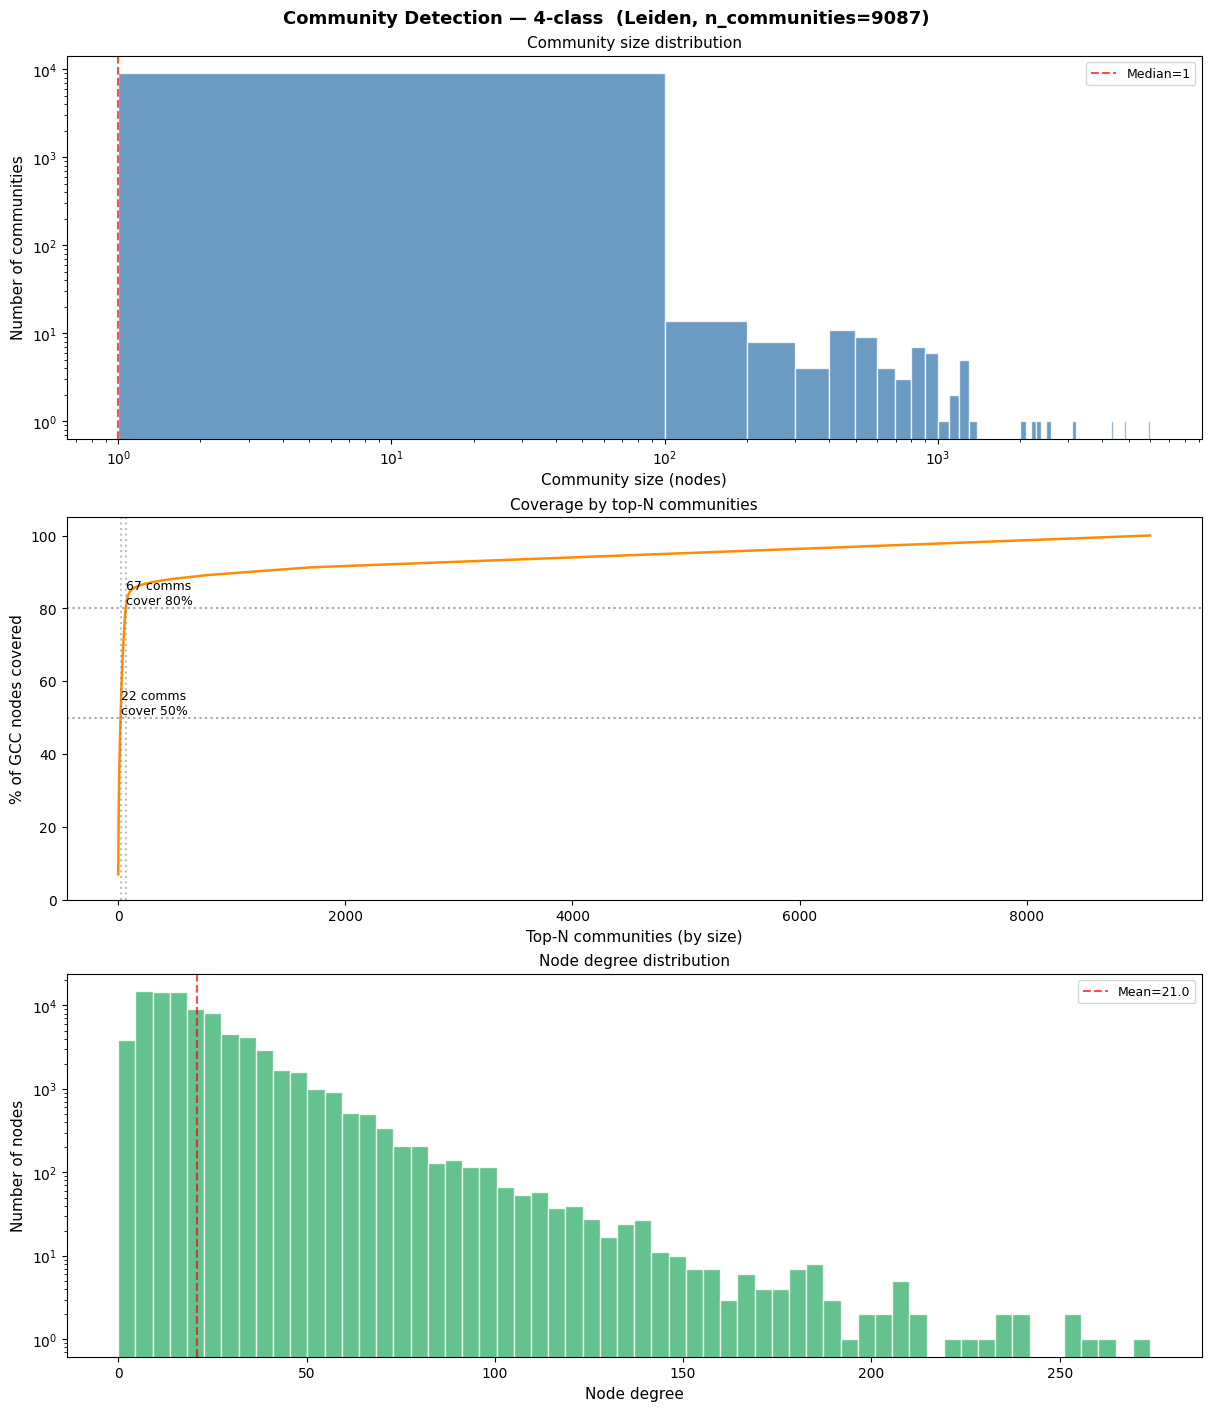

Saved: results\hierarchical_4class_t50_e20_community_stats.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True)
fig.suptitle(f'Community Detection — {"4-class" if use_4class else "Full dataset"}  '
             f'(Leiden, n_communities={n_communities})', fontsize=13, fontweight='bold')

# Plot 1: community size distribution (log scale) 
ax = axes[0]
ax.hist(comm_sizes, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Community size (nodes)', fontsize=11)
ax.set_ylabel('Number of communities', fontsize=11)
ax.set_title('Community size distribution', fontsize=11)
ax.set_xscale('log') 
ax.set_yscale('log')
ax.axvline(np.median(comm_sizes), color='red', linestyle='--', alpha=0.7,
           label=f'Median={int(np.median(comm_sizes))}')
ax.legend(fontsize=9)

# Plot 2: cumulative % of nodes covered by top-N communities 
ax = axes[1]
sorted_sizes = np.sort(comm_sizes)[::-1]
cumsum       = np.cumsum(sorted_sizes)
x_range      = np.arange(1, len(sorted_sizes)+1)
ax.plot(x_range, cumsum / n_nodes * 100, color='darkorange', linewidth=1.8)
ax.axhline(80, color='gray', linestyle=':', alpha=0.7)
ax.axhline(50, color='gray', linestyle=':', alpha=0.7)
n80 = int(np.searchsorted(cumsum / n_nodes * 100, 80)) + 1
n50 = int(np.searchsorted(cumsum / n_nodes * 100, 50)) + 1
ax.axvline(n80, color='gray', linestyle=':', alpha=0.5)
ax.axvline(n50, color='gray', linestyle=':', alpha=0.5)
ax.text(n80 + max(1, n80*0.02), 81, f'{n80} comms\ncover 80%', fontsize=9)
ax.text(n50 + max(1, n50*0.02), 51, f'{n50} comms\ncover 50%', fontsize=9)
ax.set_xlabel('Top-N communities (by size)', fontsize=11)
ax.set_ylabel('% of GCC nodes covered', fontsize=11)
ax.set_title('Coverage by top-N communities', fontsize=11)
ax.set_ylim(0, 105)

# Plot 3: degree distribution 
ax = axes[2]
degrees = [d for _, d in G.degree()]
ax.hist(degrees, bins=60, color='mediumseagreen', alpha=0.8, edgecolor='white')
ax.set_xlabel('Node degree', fontsize=11)
ax.set_ylabel('Number of nodes', fontsize=11)
ax.set_title('Node degree distribution', fontsize=11)
ax.set_yscale('log')
ax.axvline(np.mean(degrees), color='red', linestyle='--', alpha=0.7,
           label=f'Mean={np.mean(degrees):.1f}')
ax.legend(fontsize=9)

_path = artifact_path('community_stats', 'png')
plt.savefig(_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_path}')

In [11]:
# Community class purity check
# For each community, what fraction of nodes belong to the dominant class?
# High purity = communities align well with chemical taxonomy.

sid_to_klass = {r['scan_id']: r['klass'] for r in dataset}

# group node positions by community (single pass)
comm_members = defaultdict(list)
for pos in range(n_nodes):
    comm_members[mcn_pos_to_comm[pos]].append(pos)

purities = []
for cid in range(n_communities):
    klasses = [sid_to_klass[node_order_indices[p]]
               for p in comm_members.get(cid, [])
               if node_order_indices[p] in sid_to_klass]
    if not klasses:
        continue
    dominant_n = Counter(klasses).most_common(1)[0][1]
    purities.append(dominant_n / len(klasses))

purities = np.array(purities)
print(f'Community class purity ({len(purities)} communities with labeled nodes):')
print(f'  Mean purity    : {purities.mean():.3f}')
print(f'  Median purity  : {np.median(purities):.3f}')
print(f'  Purity >= 0.9  : {(purities >= 0.9).sum():,} ({(purities >= 0.9).mean()*100:.1f}%)')
print(f'  Purity >= 0.7  : {(purities >= 0.7).sum():,} ({(purities >= 0.7).mean()*100:.1f}%)')
print(f'  Purity >= 0.5  : {(purities >= 0.5).sum():,} ({(purities >= 0.5).mean()*100:.1f}%)')
print(f'  Purity <  0.5  : {(purities <  0.5).sum():,} ({(purities <  0.5).mean()*100:.1f}%)')

_purity_summary = pd.DataFrame([{
    'run_tag': RUN_TAG,
    'n_communities': len(purities),
    'mean_purity': round(float(purities.mean()), 4),
    'median_purity': round(float(np.median(purities)), 4),
    'pct_purity_ge_0.9': round(float((purities >= 0.9).mean() * 100), 2),
    'pct_purity_ge_0.7': round(float((purities >= 0.7).mean() * 100), 2),
    'pct_purity_ge_0.5': round(float((purities >= 0.5).mean() * 100), 2),
    'pct_purity_lt_0.5': round(float((purities < 0.5).mean() * 100), 2),
}])
_purity_path = artifact_path('community_purity_summary', 'csv')
_purity_summary.to_csv(_purity_path, index=False)
print(f'Saved: {_purity_path}')

'''
results explanation:
-> Average community purity is high: on average, each community is mostly made of one dominant class
-> median purity near 1.00 means at least half of the communities are perfectly pure,
   i.e. all labeled nodes inside those communities belong to the same class.
-> a high fraction of communities with purity >= 0.9 shows the molecular similarity graph and
   Leiden community detection group chemically similar spectra together.
-> only a small fraction of communities have purity < 0.5 (highly mixed / poorly aligned with labels).
'''

Community class purity (9087 communities with labeled nodes):
  Mean purity    : 0.954
  Median purity  : 1.000
  Purity >= 0.9  : 8,149 (89.7%)
  Purity >= 0.7  : 8,277 (91.1%)
  Purity >= 0.5  : 8,985 (98.9%)
  Purity <  0.5  : 102 (1.1%)
Saved: results\hierarchical_4class_t50_e20_community_purity_summary.csv


'\nresults explanation:\n-> Average community purity is high: on average, each community is mostly made of one dominant class\n-> median purity near 1.00 means at least half of the communities are perfectly pure,\n   i.e. all labeled nodes inside those communities belong to the same class.\n-> a high fraction of communities with purity >= 0.9 shows the molecular similarity graph and\n   Leiden community detection group chemically similar spectra together.\n-> only a small fraction of communities have purity < 0.5 (highly mixed / poorly aligned with labels).\n'

In [12]:
print('=' * 60)
print('SUMMARY: Community Detection')
print('=' * 60)
print(f'Dataset mode       : {"4-class" if use_4class else "Full dataset"}')
print(f'Total nodes        : {n_nodes:,}')
print(f'Network edges      : {G.number_of_edges():,}')
print(f'Total components   : {len(all_components):,}')
print(f'GCC coverage       : {comp_sizes_all[0]/n_nodes*100:.1f}% of all nodes')
print(f'Total communities  : {n_communities:,}')
print(f'  from Leiden      : {n_leiden_comps} large components')
print(f'  small clusters   : {n_small_comps}')
print(f'  singleton comms  : {n_singletons}')
print(f'Mean comm size     : {comm_sizes.mean():.1f}')
print(f'Singleton nodes    : {len(singleton_nodes):,}  ({len(singleton_nodes)/n_nodes*100:.1f}%)')
print(f'Community purity   : {purities.mean():.3f} mean  {np.median(purities):.3f} median')
print('=' * 60)

p = purities.mean()
print('\nInterpretation:')
if p > 0.7:
    print('  GOOD: High purity : communities align with chemical taxonomy.')
    print('  MCN community features are likely to help GNN classification.')
elif p > 0.5:
    print('  OK: Moderate purity : some chemical coherence in communities.')
    print('  MCN may help but gains could be modest.')
else:
    print('  WEAK: Low purity : communities mix chemical classes.')
    print('  MCN community features may add noise rather than signal.')

SUMMARY: Community Detection
Dataset mode       : 4-class
Total nodes        : 84,692
Network edges      : 888,192
Total components   : 372
GCC coverage       : 99.5% of all nodes
Total communities  : 9,087
  from Leiden      : 1 large components
  small clusters   : 14
  singleton comms  : 357
Mean comm size     : 9.3
Singleton nodes    : 357  (0.4%)
Community purity   : 0.954 mean  1.000 median

Interpretation:
  GOOD: High purity : communities align with chemical taxonomy.
  MCN community features are likely to help GNN classification.


## 8. Build MWST for every community

In [13]:
'''
For each community:
a. extract the subgraph of MASST edges within that community
b. compute a Maximum Weight Spanning Tree (highest cosine-similarity edges)
c. collect MST edges as the GNN graph
'''

# scipy has no maximum_spanning_tree, so negate weights to convert max→min problem
def maximum_spanning_tree(csr_mat):
    negated = csr_mat.copy()
    negated.data *= -1
    mst = _mst_func(negated)
    mst.data *= -1   # restore original positive weights
    return mst

# Group nodes by community
comm_to_nodes = defaultdict(list)
for mcn_pos, comm_id in mcn_pos_to_comm.items():
    comm_to_nodes[comm_id].append(mcn_pos)

mst_edges  = []   # list of (mcn_pos_u, mcn_pos_v, cosine_score)
n_skipped  = 0    # communities with 0 or 1 node (no edges possible)
n_no_edges = 0    # communities where subgraph had no edges

print(f'Building Maximum Weight Spanning Tree for {n_communities:,} communities ...')
for cid in range(n_communities):
    members = comm_to_nodes[cid]

    if len(members) <= 1:
        n_skipped += 1
        continue

    local_idx       = {mcn_pos: i for i, mcn_pos in enumerate(members)}
    n_c             = len(members)
    rows, cols, wts = [], [], []

    for u in members:
        for v in G.neighbors(u):
            if mcn_pos_to_comm.get(v) == cid and v in local_idx:
                rows.append(local_idx[u])
                cols.append(local_idx[v])
                wts.append(G.edges[u, v]['cosine_score'])

    if not rows:
        n_no_edges += 1
        continue

    # Build sparse matrix with raw (positive) cosine scores
    mat = _csr_mat(
        (np.array(wts, dtype=np.float32), (rows, cols)),
        shape=(n_c, n_c)
    )

    # Maximum spanning tree: keeps highest-cosine edges
    mst = maximum_spanning_tree(mat).tocoo()

    for r, c, w in zip(mst.row, mst.col, mst.data):
        mst_edges.append((members[r], members[c], float(w)))

print(f'Done.')
print(f'  MWST edges built    : {len(mst_edges):,}')
print(f'  Skipped (size <= 1) : {n_skipped:,}')
print(f'  No internal edges   : {n_no_edges:,}')

Building Maximum Weight Spanning Tree for 9,087 communities ...
Done.
  MWST edges built    : 75,600
  Skipped (size <= 1) : 7,411
  No internal edges   : 0


In [14]:
# MWST edge statistics

mst_weights = np.array([w for _, _, w in mst_edges], dtype=np.float32)

# how many training nodes appear in at least one MST edge?
nodes_in_mst = set()
for u, v, _ in mst_edges:
    nodes_in_mst.add(u)
    nodes_in_mst.add(v)

nodes_not_in_mst = set(range(n_nodes)) - nodes_in_mst

print(f'MWST edge statistics:')
print(f'  Total MWST edges        : {len(mst_edges):,}')
print(f'  Original MASST edges   : {G.number_of_edges():,}')
print(f'  Edge reduction         : {(1 - len(mst_edges)/G.number_of_edges())*100:.1f}%')
print(f'  Edge weight min        : {mst_weights.min():.4f}')
print(f'  Edge weight mean       : {mst_weights.mean():.4f}')
print(f'  Edge weight max        : {mst_weights.max():.4f}')
print(f'\nNode connectivity:')
print(f'  Nodes with MWST edge    : {len(nodes_in_mst):,}  ({len(nodes_in_mst)/n_nodes*100:.1f}%)')
print(f'  Nodes without MWST edge : {len(nodes_not_in_mst):,}  ({len(nodes_not_in_mst)/n_nodes*100:.1f}%)')
print(f'  (nodes without MWST edges = truly isolated nodes with no graph connections)')

# Compare singleton count before and after MST
print(f'\nSingleton comparison:')
print(f'  Before MCN (MASST graph)  : {len(singleton_nodes):,} singletons')
print(f'  After MCN (MWST edges)     : {len(nodes_not_in_mst):,} nodes without any edge')
reduction = (len(singleton_nodes) - len(nodes_not_in_mst))
print(f'  Reduction                 : {reduction:,} nodes rescued by MCN')

MWST edge statistics:
  Total MWST edges        : 75,600
  Original MASST edges   : 888,192
  Edge reduction         : 91.5%
  Edge weight min        : 0.0000
  Edge weight mean       : 0.5941
  Edge weight max        : 0.9995

Node connectivity:
  Nodes with MWST edge    : 77,274  (91.2%)
  Nodes without MWST edge : 7,418  (8.8%)
  (nodes without MWST edges = truly isolated nodes with no graph connections)

Singleton comparison:
  Before MCN (MASST graph)  : 357 singletons
  After MCN (MWST edges)     : 7,418 nodes without any edge
  Reduction                 : -7,061 nodes rescued by MCN


## 9. Convert MWST edges to Pytorch Tensors

In [15]:
# MWST edges are already in GLOBAL node positions (the graph was built over all nodes),
# so they map directly to GNN node indices — no train-local remapping is needed.
if mst_edges:
    src_list = [u for u, v, w in mst_edges]
    dst_list = [v for u, v, w in mst_edges]
    wts_list = [w for u, v, w in mst_edges]

    # Make bidirectional (GNN needs edges in both directions)
    src_bi = src_list + dst_list
    dst_bi = dst_list + src_list
    wts_bi = wts_list + wts_list

    mcn_edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)
    mcn_edge_attr  = torch.tensor(wts_bi, dtype=torch.float32).unsqueeze(1)
else:
    mcn_edge_index = torch.zeros((2, 0), dtype=torch.long)
    mcn_edge_attr  = torch.zeros((0, 1), dtype=torch.float32)

print(f'mcn_edge_index : {mcn_edge_index.shape}  (2 x num_edges, bidirectional)')
print(f'mcn_edge_attr  : {mcn_edge_attr.shape}   (cosine similarity weight)')
print('Transductive graph: message passing spans train + val + test nodes.')

mcn_edge_index : torch.Size([2, 151200])  (2 x num_edges, bidirectional)
mcn_edge_attr  : torch.Size([151200, 1])   (cosine similarity weight)
Transductive graph: message passing spans train + val + test nodes.


## 10. Visualize MWST effect

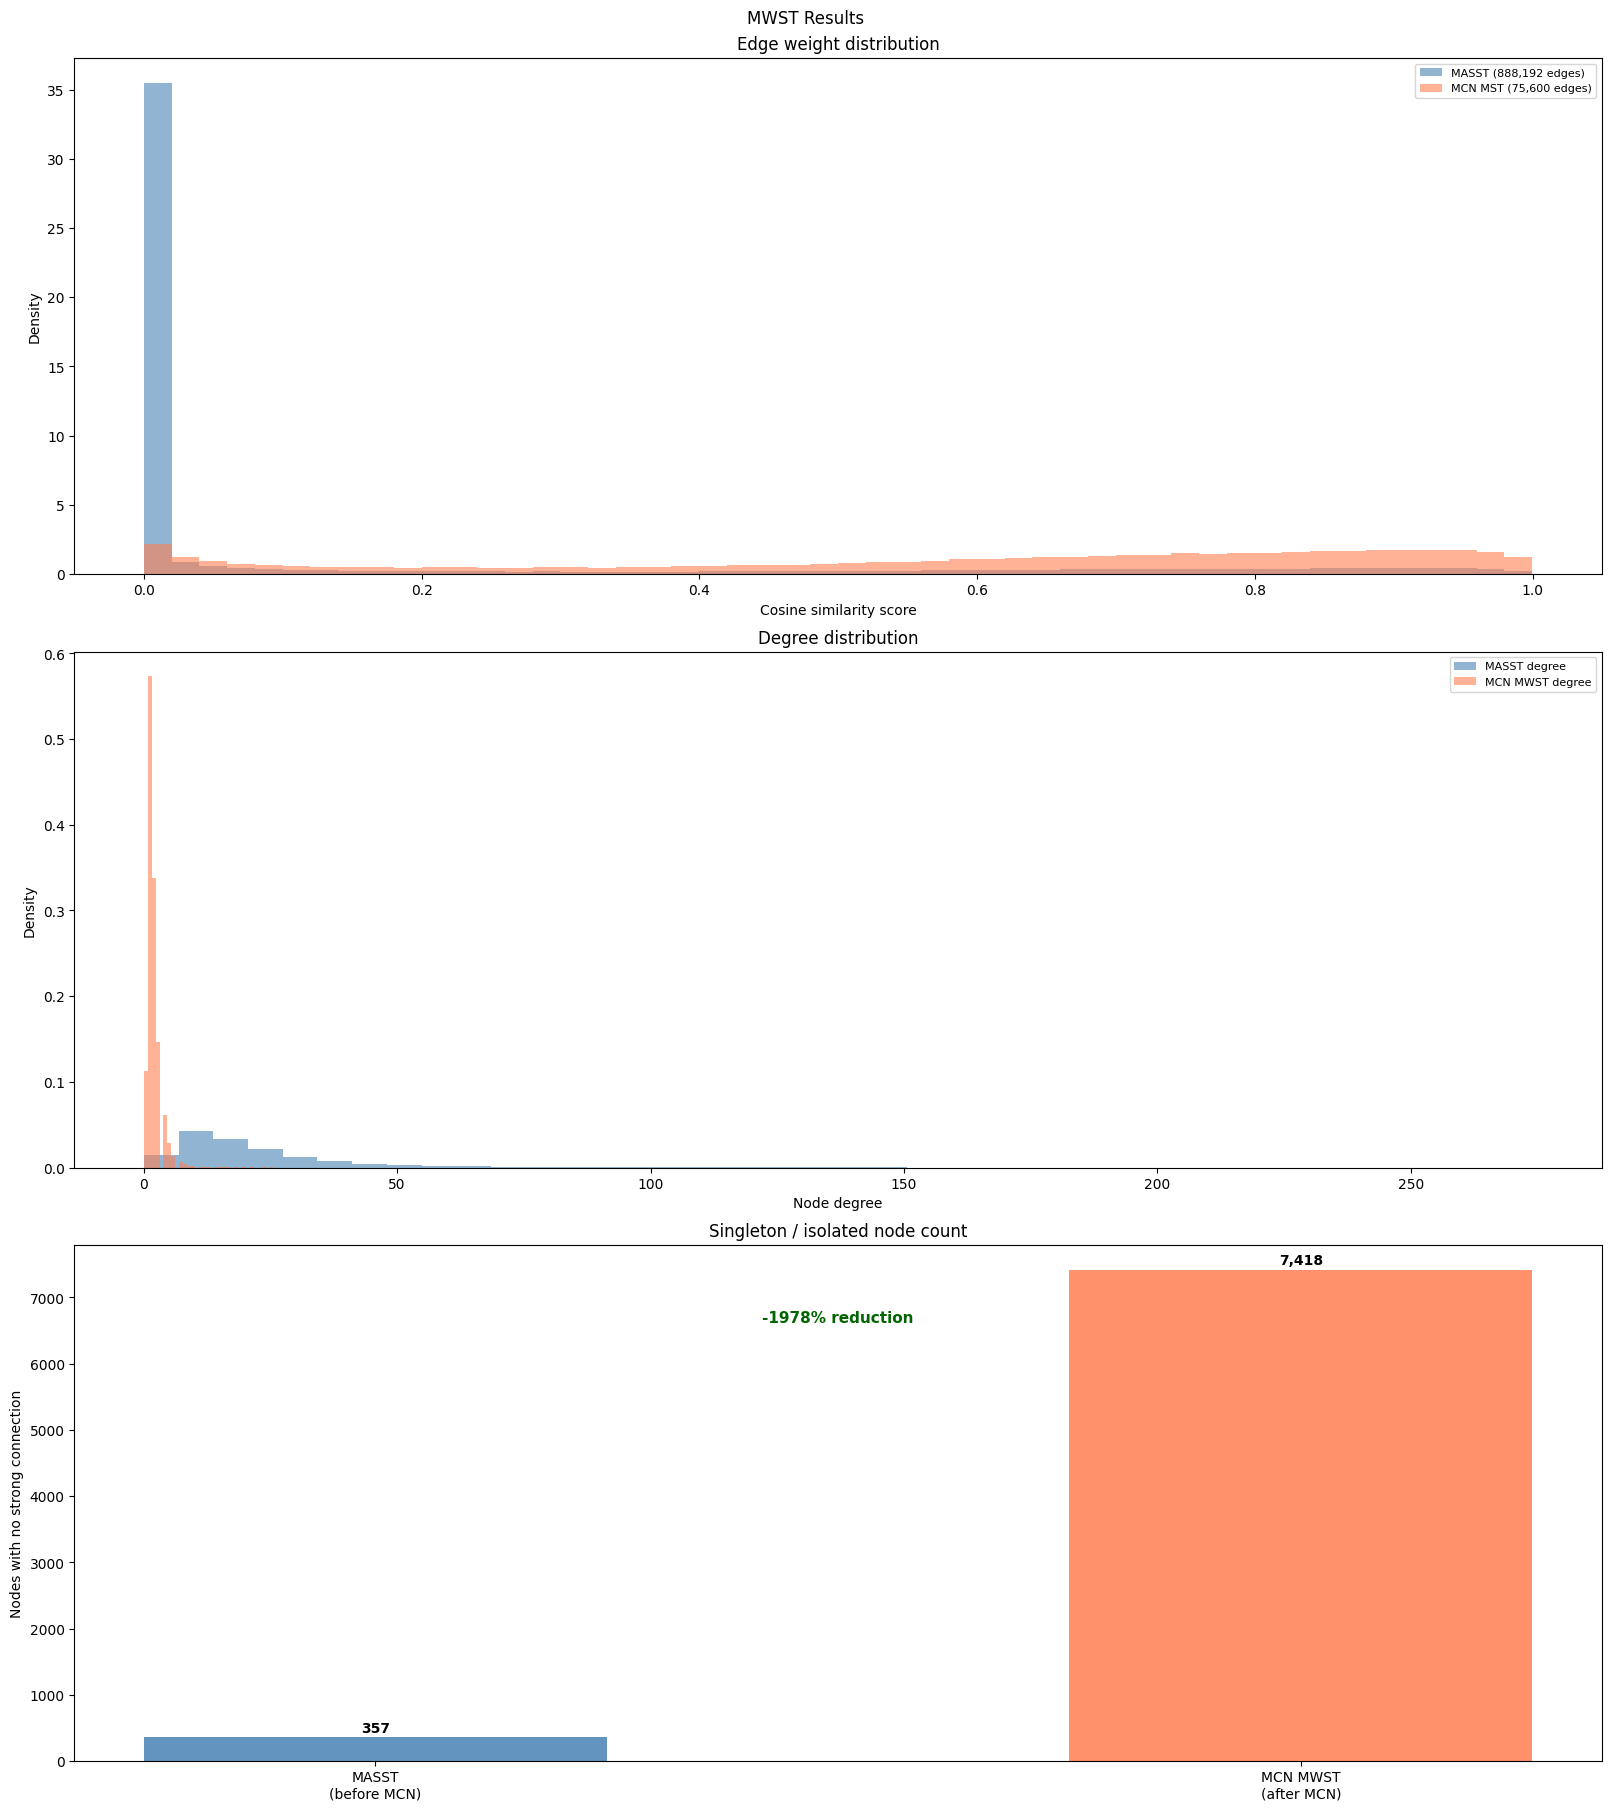

Saved: results\hierarchical_4class_t50_e20_mst_analysis.png


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18), constrained_layout=True)
fig.suptitle('MWST Results', fontsize=12)

# Plot 1: edge weight distribution comparison
ax = axes[0]
masst_weights = np.array([G.edges[u, v]['cosine_score']
                           for u, v in G.edges()], dtype=np.float32)
ax.hist(masst_weights, bins=50, alpha=0.6, label=f'MASST ({len(masst_weights):,} edges)',
        color='steelblue', density=True)
ax.hist(mst_weights,   bins=50, alpha=0.6, label=f'MCN MST ({len(mst_weights):,} edges)',
        color='coral',    density=True)
ax.set_xlabel('Cosine similarity score')
ax.set_ylabel('Density')
ax.set_title('Edge weight distribution')
ax.legend(fontsize=8)

# Plot 2: edges per node (degree) before and after MST
ax = axes[1]
masst_degree = dict(G.degree())
mst_degree   = defaultdict(int)
for u, v, _ in mst_edges:
    mst_degree[u] += 1
    mst_degree[v] += 1
masst_deg_arr = np.array([masst_degree.get(i, 0) for i in range(n_nodes)])
mst_deg_arr   = np.array([mst_degree.get(i, 0)   for i in range(n_nodes)])
ax.hist(masst_deg_arr, bins=40, alpha=0.6, label='MASST degree', color='steelblue', density=True)
ax.hist(mst_deg_arr,   bins=40, alpha=0.6, label='MCN MWST degree', color='coral', density=True)
ax.set_xlabel('Node degree')
ax.set_ylabel('Density')
ax.set_title('Degree distribution')
ax.legend(fontsize=8)

# Plot 3: singleton comparison bar chart
ax = axes[2]
categories = ['MASST\n(before MCN)', 'MCN MWST\n(after MCN)']
counts      = [len(singleton_nodes), len(nodes_not_in_mst)]
colors      = ['steelblue', 'coral']
bars = ax.bar(categories, counts, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(counts)*0.01,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Nodes with no strong connection')
ax.set_title('Singleton / isolated node count')
reduction_pct = (counts[0] - counts[1]) / max(counts[0], 1) * 100
ax.text(0.5, 0.85, f'{reduction_pct:.0f}% reduction',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='darkgreen', fontweight='bold')

_path = artifact_path('mst_analysis', 'png')
plt.savefig(_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_path}')

## 11. Build Spectral Node Features

In [17]:
def peaks_to_features(peaks, top_k=20):
    """
    Convert a spectrum to a 340-dim feature vector.
    Each of the top-20 peaks (by intensity) contributes 17 features:
      - 16: sinusoidal m/z encoding (8 sin + 8 cos at log-spaced wavelengths)
      -  1: normalised intensity
    """
    n_out = top_k * 17

    # empty spectrum → zero vector
    if peaks is None or len(peaks) == 0:
        return np.zeros(n_out, dtype=np.float32)

    p = peaks.astype(np.float32)

    # keep top-k peaks by intensity; zero-pad if fewer than top_k
    p = p[np.argsort(p[:, 1])[::-1][:top_k]]
    if len(p) < top_k:
        pad = np.zeros((top_k - len(p), 2), dtype=np.float32)
        p   = np.vstack([p, pad])

    mz    = p[:, 0]                          # (top_k,)
    inten = p[:, 1]
    inten = inten / max(inten.max(), 1e-6)   # normalise to 0-1

    # 8 wavelengths log-spaced between 0.1 and 1000 Da
    wavelengths = np.logspace(-1, 3, num=8, dtype=np.float32)   # (8,)

    # sinusoidal encoding of m/z: sin and cos at each wavelength
    angles = (2 * np.pi * mz[:, None]) / wavelengths[None, :]   # (top_k, 8)
    sin_enc = np.sin(angles)   # (top_k, 8)
    cos_enc = np.cos(angles)   # (top_k, 8)

    # interleave sin/cos → (top_k, 16), then append intensity → (top_k, 17)
    enc = np.empty((top_k, 16), dtype=np.float32)
    enc[:, 0::2] = sin_enc
    enc[:, 1::2] = cos_enc
    features = np.concatenate([enc, inten[:, None]], axis=1)   # (top_k, 17)

    return features.flatten()   # (340,)


# build features for all nodes  
scan_to_ds_idx = {r['scan_id']: i for i, r in enumerate(dataset)}

print('Building spectral features for all nodes ...')
raw_x = np.stack(
    [peaks_to_features(dataset[scan_to_ds_idx[sid]]['peaks'])
     for sid in node_order_indices],
    axis=0
).astype(np.float32)
print(f'raw_x shape : {raw_x.shape}  (n_nodes × 340)')

# normalise using training statistics only (no leakage)
train_rows = np.array([scan_to_pos[sid] for sid in train_scan_ids
                       if sid in scan_to_pos], dtype=np.int64)
feat_mean  = raw_x[train_rows].mean(axis=0, keepdims=True)
feat_std   = raw_x[train_rows].std(axis=0,  keepdims=True).clip(min=1e-6)
x_spec     = ((raw_x - feat_mean) / feat_std).astype(np.float32)

print(f'Normalised on {len(train_rows):,} training nodes only')
print(f'x_spec shape : {x_spec.shape}')

Building spectral features for all nodes ...
raw_x shape : (84692, 340)  (n_nodes × 340)
Normalised on 59,283 training nodes only
x_spec shape : (84692, 340)


## 12. Community Features

Compute 4 structural features per node from the MCN community structure.

| Feature | Description |
|---|---|
| `log_size` | Log of community size — larger = more chemically coherent |
| `degree_cent` | Node degree within its community / (size-1) — hub vs peripheral |
| `dist_centroid` | Euclidean distance to community centroid in spectral space |
| `singleton_flag` | 1.0 if no strong neighbor (cosine < threshold), else 0.0 |

Computed for **all** nodes (train + val + test) from the transductive network — labels are never used.

In [18]:
# Community features for ALL nodes (transductive: train + val + test).
# Indexed by global node position so they align with x_spec / masks / labels.
# Only spectral similarity and graph structure are used — labels are never touched.

node_comm_id   = np.array([mcn_pos_to_comm[i] for i in range(n_nodes)], dtype=np.int64)
comm_sizes_arr = np.bincount(node_comm_id, minlength=n_communities)

# Community centroids: mean spectral feature of all members
comm_centroids = np.zeros((n_communities, x_spec.shape[1]), dtype=np.float32)
np.add.at(comm_centroids, node_comm_id, x_spec)
comm_centroids /= np.maximum(comm_sizes_arr[:, None], 1)   # avoid divide-by-zero

# Feature 1: log_size — larger communities tend to be well-populated chemical families
f_log_size = np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)

# Feature 2: degree_centrality — intra-community connectivity (hub vs peripheral)
degree_arr    = np.array([G.degree(i) for i in range(n_nodes)], dtype=np.float32)
size_m1       = np.maximum(comm_sizes_arr[node_comm_id] - 1, 1).astype(np.float32)
f_degree_cent = (degree_arr / size_m1).clip(0, 1)

# Feature 3: dist_to_centroid — spectral distance to the community centroid
diffs       = x_spec - comm_centroids[node_comm_id]
f_dist_cent = np.linalg.norm(diffs, axis=1).astype(np.float32)

# Feature 4: singleton_flag — 1.0 if the node had no strong neighbor
f_singleton = np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],
                       dtype=np.float32)

print('Community features built for all nodes:')
print(f'  log_size        : mean={f_log_size.mean():.2f}  max={f_log_size.max():.2f}')
print(f'  degree_cent     : mean={f_degree_cent.mean():.4f}  max={f_degree_cent.max():.4f}')
print(f'  dist_centroid   : mean={f_dist_cent.mean():.4f}  max={f_dist_cent.max():.4f}')
print(f'  singleton_flag  : {int(f_singleton.sum())} singletons ({f_singleton.mean()*100:.1f}%)')

Community features built for all nodes:
  log_size        : mean=6.22  max=8.70
  degree_cent     : mean=0.1783  max=1.0000
  dist_centroid   : mean=15.8964  max=43.4531
  singleton_flag  : 357 singletons (0.4%)


## 13. Assemble 344-dim Node Features + Labels + Masks

In [19]:
# Community features are already computed for all nodes (global position order).
comm_features = np.stack(
    [f_log_size, f_degree_cent, f_dist_cent, f_singleton], axis=1
).astype(np.float32)

# 344-dim node features
x_aug     = np.concatenate([x_spec, comm_features], axis=1).astype(np.float32)
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
x_aug_dev = torch.tensor(x_aug, dtype=torch.float32).to(device)
print(f'Device    : {device}')
print(f'x_aug_dev : {x_aug_dev.shape}  (340 spectral + 4 MCN community)')

# label encoding
from sklearn.preprocessing import LabelEncoder
all_sc_labels = sorted(set(r['superclass'] for r in dataset if r['superclass'].strip()))
all_cl_labels = sorted(set(r['klass']      for r in dataset if r['klass'].strip()))
le_sc = LabelEncoder(); le_sc.fit(all_sc_labels)
le_cl = LabelEncoder(); le_cl.fit(all_cl_labels)
n_sc  = len(le_sc.classes_)
n_cl  = len(le_cl.classes_)

sid_to_labels = {r['scan_id']: r for r in dataset}

# use -1 sentinel for nodes with empty/missing labels
y_sc = [
    int(le_sc.transform([sid_to_labels[sid]['superclass']])[0])
    if sid in sid_to_labels and sid_to_labels[sid]['superclass'].strip()
    else -1
    for sid in node_order_indices
]
y_cl = [
    int(le_cl.transform([sid_to_labels[sid]['klass']])[0])
    if sid in sid_to_labels and sid_to_labels[sid]['klass'].strip()
    else -1
    for sid in node_order_indices
]
y_sc_dev = torch.tensor(y_sc, dtype=torch.long).to(device)
y_cl_dev = torch.tensor(y_cl, dtype=torch.long).to(device)

# Boolean masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask   = torch.zeros(n_nodes, dtype=torch.bool)
test_mask  = torch.zeros(n_nodes, dtype=torch.bool)
for i, sid in enumerate(node_order_indices):
    if   sid in train_scan_ids: train_mask[i] = True
    elif sid in val_scan_ids:   val_mask[i]   = True
    elif sid in test_scan_ids:  test_mask[i]  = True

# Exclude nodes with missing labels from all masks
valid_label_mask = torch.tensor([v != -1 for v in y_cl], dtype=torch.bool)
train_mask = train_mask & valid_label_mask
val_mask   = val_mask   & valid_label_mask
test_mask  = test_mask  & valid_label_mask

train_mask_dev = train_mask.to(device)
val_mask_dev   = val_mask.to(device)
test_mask_dev  = test_mask.to(device)
print(f'Masks: train={train_mask.sum():,}  val={val_mask.sum():,}  test={test_mask.sum():,}')
n_missing = (valid_label_mask == False).sum().item()
if n_missing:
    print(f'  ({n_missing} nodes excluded from all masks — empty labels)')

Device    : cuda
x_aug_dev : torch.Size([84692, 344])  (340 spectral + 4 MCN community)
Masks: train=59,283  val=8,470  test=16,939


## 14. Hierarchy Mask + Class Weights

In [20]:
# hierarchy mask

# sc_to_cl_mask[sc_id, cl_id] = True means cl is a valid child of sc

# used at inference to mask impossible class predictions (hierarchical constraint)

sc_to_cl_mask = torch.zeros(n_sc, n_cl, dtype=torch.bool)
for r in dataset:
    if not r['superclass'] or not r['klass']: continue
    sc_id = int(le_sc.transform([r['superclass']])[0])
    cl_id = int(le_cl.transform([r['klass']])[0])
    sc_to_cl_mask[sc_id, cl_id] = True

sc_to_cl_mask_dev = sc_to_cl_mask.to(device)
print(f'Hierarchy mask : {sc_to_cl_mask.shape}')
print(f'Avg valid classes per superclass : {sc_to_cl_mask.float().sum(1).mean():.1f}')

# class weights (inverse frequency on training nodes)
# downweights majority classes, upweights rare classes
def make_class_weights(y_tensor, mask, n_classes):
    counts = np.bincount(y_tensor[mask].cpu().numpy(), minlength=n_classes).astype(float)
    w = 1.0 / counts.clip(min=1)
    return torch.tensor((w / w.sum() * n_classes).astype(np.float32)).to(device)

sc_wts = make_class_weights(y_sc_dev, train_mask_dev, n_sc)
cl_wts = make_class_weights(y_cl_dev, train_mask_dev, n_cl)
print(f'SC class weights: min={sc_wts.min():.3f}  max={sc_wts.max():.3f}')
print(f'CL class weights: min={cl_wts.min():.3f}  max={cl_wts.max():.3f}')

Hierarchy mask : torch.Size([4, 4])
Avg valid classes per superclass : 1.0
SC class weights: min=0.385  max=1.530
CL class weights: min=0.385  max=1.530


## 15. Prepare Graph Edges (Transductive)

The transductive molecular network is used for both training and evaluation: message
passing spans all nodes (train + val + test), while the training loss is masked to
training nodes. Because the graph comes only from spectral similarity (never labels),
this is leakage-free transductive learning.

In [21]:
# Transductive molecular network edges — the SAME graph for training and eval.
# Message passing spans all nodes; the training loss is masked to training nodes,
# so labels are never shared -> leakage-free transductive learning.
mcn_ei_train_dev = mcn_ei_eval_dev = mcn_edge_index.to(device)
mcn_ea_train_dev = mcn_ea_eval_dev = mcn_edge_attr.to(device)

# connectivity report for val/test nodes
_deg = torch.zeros(n_nodes, device=device)
_deg.index_add_(0, mcn_ei_train_dev[0],
                torch.ones(mcn_ei_train_dev.shape[1], device=device))
_vt = (val_mask_dev | test_mask_dev)
print(f'Transductive MCN edges       : {mcn_ei_train_dev.shape[1]:,} (bidirectional)')
print(f'Val/test nodes with >=1 edge : {int((_deg[_vt] > 0).sum()):,}/{int(_vt.sum()):,}')

Transductive MCN edges       : 151,200 (bidirectional)
Val/test nodes with >=1 edge : 23,137/25,409


## 16. Model Architecture

In [22]:
class SpecGNNBlock(nn.Module):
    """One GAT layer with DropEdge + residual + LayerNorm.
    Identical to the baseline SpecGNN block — no changes.
    """
    def __init__(self, in_ch, out_ch, num_heads=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        assert out_ch % num_heads == 0
        self.drop_edge_p = drop_edge_p
        self.conv = GATConv(
            in_ch, out_ch // num_heads, heads=num_heads,
            concat=True, dropout=dropout, edge_dim=1,
            add_self_loops=False,
        )
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, training=False):
        if training and self.drop_edge_p > 0:
            # Randomly drop edges during training for regularisation
            edge_index, mask = dropout_edge(
                edge_index, p=self.drop_edge_p,
                force_undirected=True, training=True,
            )
            edge_attr = edge_attr[mask]
        h = self.act(self.conv(x, edge_index, edge_attr=edge_attr))
        return self.norm(self.drop(h) + self.res(x))   # residual connection


class HierarchicalSpecGNN(nn.Module):
    """Hierarchical GAT-GNN for superclass + class prediction.

    Architecture:
        Input (344-dim) → LayerNorm → Linear projection (128-dim)
        → N x SpecGNNBlock (GAT + residual + LayerNorm)
        → Jump-Knowledge concat → Linear (128-dim)
        → Superclass head (n_sc logits)
        → Class head      (n_cl logits)

    At inference, class logits are masked by the predicted superclass
    so the model can never predict a class inconsistent with its superclass.
    """
    def __init__(self, feat_dim=344, hidden=128, num_layers=2, num_heads=4,
                 n_superclass=4, n_class=4, dropout=0.3, drop_edge_p=0.1):
        super().__init__()
        self.norm_in = nn.LayerNorm(feat_dim)
        self.proj    = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden),
            nn.GELU(), nn.Dropout(dropout),
        )
        self.layers = nn.ModuleList([
            SpecGNNBlock(hidden, hidden, num_heads, dropout, drop_edge_p)
            for _ in range(num_layers)
        ])
        # Jump-Knowledge: concat all layer outputs, project back to hidden
        self.jk = nn.Sequential(
            nn.Linear(hidden * (num_layers + 1), hidden),
            nn.LayerNorm(hidden), nn.GELU(),
        )
        # Superclass head (coarser prediction)
        self.sc_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, n_superclass),
        )
        # Class head (finer prediction)
        self.cl_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, n_class),
        )

    def encode(self, x, edge_index, edge_attr, training=False):
        """Shared encoder — produces node embeddings."""
        x  = self.norm_in(x)
        h  = self.proj(x)
        hs = [h]   # collect all layer outputs for Jump-Knowledge
        for layer in self.layers:
            h = layer(h, edge_index, edge_attr, training=training)
            hs.append(h)
        return self.jk(torch.cat(hs, dim=-1))

    def forward(self, x, edge_index, edge_attr, training=False):
        """Returns (sc_logits, cl_logits) — raw, unmasked."""
        emb = self.encode(x, edge_index, edge_attr, training=training)
        return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, edge_index, edge_attr, sc_to_cl_mask_dev):
        """Inference with hierarchical constraint.
        Class logits for classes inconsistent with the predicted superclass
        are set to -inf before softmax, so they get zero probability.
        """
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg  = self.forward(x, edge_index, edge_attr)
            # For each node, look up which classes are valid for its predicted SC
            valid_mask    = sc_to_cl_mask_dev[sc_lg.argmax(1)]   # (N, n_cl)
            cl_lg_masked  = cl_lg.masked_fill(~valid_mask, float('-inf'))
        return sc_lg, cl_lg_masked


print('HierarchicalSpecGNN defined.')
print(f'  Input  : {x_aug_dev.shape[1]}-dim  (340 spectral + 4 MCN community)')
print(f'  SC head: {n_sc} superclasses → {list(le_sc.classes_)}')
print(f'  CL head: {n_cl} classes      → {list(le_cl.classes_)}')

HierarchicalSpecGNN defined.
  Input  : 344-dim  (340 spectral + 4 MCN community)
  SC head: 4 superclasses → [np.str_('Benzenoids'), np.str_('Lipids and lipid-like molecules'), np.str_('Organic acids and derivatives'), np.str_('Organic oxygen compounds')]
  CL head: 4 classes      → [np.str_('Benzene and substituted derivatives'), np.str_('Carboxylic acids and derivatives'), np.str_('Fatty Acyls'), np.str_('Organooxygen compounds')]


## Train Model 

In [23]:
# Hyperparameters 
hidden       = 128
num_layers   = 2
num_heads    = 4
dropout      = 0.3
drop_edge_p  = 0.1
epochs       = 200
lr           = 1e-3
patience     = 20
w_sc         = 0.3   # loss weight for superclass head
w_cl         = 0.7   # loss weight for class head (primary task)

# Build model
model = HierarchicalSpecGNN(
    feat_dim     = x_aug_dev.shape[1],   # 344-dim
    hidden       = hidden,
    num_layers   = num_layers,
    num_heads    = num_heads,
    n_superclass = n_sc,
    n_class      = n_cl,
    dropout      = dropout,
    drop_edge_p  = drop_edge_p,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# Optimizer + scheduler + loss
opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='max', factor=0.5, patience=10, min_lr=1e-6)
crit_sc = nn.CrossEntropyLoss(weight=sc_wts)   # weighted by inverse class frequency
crit_cl = nn.CrossEntropyLoss(weight=cl_wts)

# Training state
best_val_f1 = 0.0
best_state  = None
best_ep     = 0
es_ctr      = 0   # early stopping counter

history = {
    'loss'      : [],
    'tr_sc_acc' : [], 'tr_cl_acc' : [],
    'val_sc_acc': [], 'val_cl_acc': [],
    'val_sc_f1' : [], 'val_cl_f1' : [],
}

print('Training Model  (Transductive MCN) ...')
print(f'  Edges   : all-node MCN MST  ({mcn_ei_train_dev.shape[1]:,} edges; loss masked to train)')
print(f'  Features: {x_aug_dev.shape[1]}-dim (spectral + MCN community)')
print(f'  Epochs  : {epochs}  Patience: {patience}')
print()
print(f'  {"ep":>4}  {"loss":>8}  {"tr_sc_acc":>10}  {"tr_cl_acc":>10}  '
      f'{"val_sc_acc":>11}  {"val_cl_acc":>11}  {"val_sc_f1":>10}  {"val_cl_f1":>10}')
print('  ' + '-' * 90)

for epoch in range(1, epochs + 1):

    # Train
    model.train()
    opt.zero_grad()
    sc_logits, cl_logits = model(
        x_aug_dev, mcn_ei_train_dev, mcn_ea_train_dev, training=True)

    # Loss computed on training nodes only
    loss_sc = crit_sc(sc_logits[train_mask_dev], y_sc_dev[train_mask_dev])
    loss_cl = crit_cl(cl_logits[train_mask_dev], y_cl_dev[train_mask_dev])
    loss    = w_sc * loss_sc + w_cl * loss_cl

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # prevent gradient explosion
    opt.step()

    # Training accuracy (no extra forward pass — reuse logits from above) 
    with torch.no_grad():
        tr_sc_acc = (sc_logits[train_mask_dev].argmax(1) == y_sc_dev[train_mask_dev]).float().mean().item()
        tr_cl_acc = (cl_logits[train_mask_dev].argmax(1) == y_cl_dev[train_mask_dev]).float().mean().item()

    # Validate
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(
            x_aug_dev, mcn_ei_eval_dev, mcn_ea_eval_dev, sc_to_cl_mask_dev)

        val_sc_acc = (sc_lg[val_mask_dev].argmax(1) == y_sc_dev[val_mask_dev]).float().mean().item()
        val_cl_acc = (cl_lgm[val_mask_dev].argmax(1) == y_cl_dev[val_mask_dev]).float().mean().item()

        val_sc_f1  = f1_score(
            y_sc_dev[val_mask_dev].cpu(),
            sc_lg[val_mask_dev].argmax(1).cpu(),
            average='macro', zero_division=0)
        val_cl_f1  = f1_score(
            y_cl_dev[val_mask_dev].cpu(),
            cl_lgm[val_mask_dev].argmax(1).cpu(),
            average='macro', zero_division=0)

    # Step LR scheduler on val class F1 (primary metric)
    sched.step(val_cl_f1)

    # Log 
    history['loss'].append(loss.item())
    history['tr_sc_acc'].append(tr_sc_acc)
    history['tr_cl_acc'].append(tr_cl_acc)
    history['val_sc_acc'].append(val_sc_acc)
    history['val_cl_acc'].append(val_cl_acc)
    history['val_sc_f1'].append(val_sc_f1)
    history['val_cl_f1'].append(val_cl_f1)

    print(f'  {epoch:4d}  {loss.item():8.4f}  '
          f'{tr_sc_acc*100:9.1f}%  {tr_cl_acc*100:9.1f}%  '
          f'{val_sc_acc*100:10.1f}%  {val_cl_acc*100:10.1f}%  '
          f'{val_sc_f1:10.3f}  {val_cl_f1:10.3f}')

    # Early stopping + best model checkpoint 
    if val_cl_f1 > best_val_f1 + 1e-4:
        best_val_f1 = val_cl_f1
        best_ep     = epoch
        es_ctr      = 0
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        es_ctr += 1

    if es_ctr >= patience:
        print(f'\n  Early stop at epoch {epoch} (no improvement for {patience} epochs)')
        break

print(f'\nTraining complete.  Best epoch={best_ep}  val_cl_f1={best_val_f1:.4f} tr_sc_acc= {tr_sc_acc:.4f} tr_cl_acc= {tr_cl_acc:.4f} val_sc_acc= {val_sc_acc:.4f} val_cl_acc= {val_cl_acc:.4f}')

# Persist best model + everything needed for standalone inference
_model_path = artifact_path('model', 'pt')
torch.save({
    'run_tag': RUN_TAG,
    'model_state_dict': best_state,
    'model_config': {
        'feat_dim': x_aug_dev.shape[1],
        'hidden': hidden,
        'num_layers': num_layers,
        'num_heads': num_heads,
        'n_superclass': n_sc,
        'n_class': n_cl,
        'dropout': dropout,
        'drop_edge_p': drop_edge_p,
    },
    'training': {
        'best_epoch': best_ep,
        'best_val_cl_f1': best_val_f1,
        'epochs_ran': len(history['loss']),
        'lr': lr, 'patience': patience, 'w_sc': w_sc, 'w_cl': w_cl,
    },
    'label_encoders': {
        'superclass_classes': list(le_sc.classes_),
        'class_classes': list(le_cl.classes_),
    },
    'feature_norm': {'feat_mean': feat_mean, 'feat_std': feat_std},
    'community': {
        'comm_centroids': comm_centroids,
        'comm_sizes_arr': comm_sizes_arr,
    },
    'hierarchy_mask': sc_to_cl_mask.cpu(),
}, _model_path)
print(f'Saved model checkpoint: {_model_path}')

Model parameters: 146,232
Training Model  (Transductive MCN) ...
  Edges   : all-node MCN MST  (151,200 edges; loss masked to train)
  Features: 344-dim (spectral + MCN community)
  Epochs  : 200  Patience: 20

    ep      loss   tr_sc_acc   tr_cl_acc   val_sc_acc   val_cl_acc   val_sc_f1   val_cl_f1
  ------------------------------------------------------------------------------------------
     1    1.3960       36.3%       14.1%        45.8%        45.8%       0.326       0.326
     2    1.3766       37.4%       28.9%        46.1%        46.1%       0.346       0.346
     3    1.3608       38.5%       41.7%        46.7%        46.7%       0.348       0.348
     4    1.3438       40.7%       46.5%        48.4%        48.4%       0.355       0.355
     5    1.3239       44.1%       49.0%        50.3%        50.3%       0.361       0.361
     6    1.3051       46.5%       50.2%        51.7%        51.7%       0.365       0.365
     7    1.2877       48.9%       51.2%        52.6%      

In [24]:
# Restore best checkpoint
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
model.eval()

with torch.no_grad():
    sc_lg, cl_lgm = model.predict(
        x_aug_dev, mcn_ei_eval_dev, mcn_ea_eval_dev, sc_to_cl_mask_dev)

te_sc_p = sc_lg[test_mask_dev].argmax(1).cpu().numpy()
te_sc_t = y_sc_dev[test_mask_dev].cpu().numpy()
te_cl_p = cl_lgm[test_mask_dev].argmax(1).cpu().numpy()
te_cl_t = y_cl_dev[test_mask_dev].cpu().numpy()

sc_acc = round((te_sc_p == te_sc_t).mean() * 100, 2)
sc_f1  = round(f1_score(te_sc_t, te_sc_p, average='macro', zero_division=0), 4)
cl_acc = round((te_cl_p == te_cl_t).mean() * 100, 2)
cl_f1  = round(f1_score(te_cl_t, te_cl_p, average='macro', zero_division=0), 4)

print(f'Test Results')
print(f'  SuperClass acc={sc_acc}%  SuperClass F1={sc_f1}')
print(f'  Class acc={cl_acc}%  Class F1={cl_f1}')

_metrics_path = artifact_path('test_metrics', 'csv')
pd.DataFrame([{
    'run_tag': RUN_TAG,
  'split': 'test',
    'superclass_accuracy_pct': sc_acc,
    'superclass_macro_f1': sc_f1,
    'class_accuracy_pct': cl_acc,
    'class_macro_f1': cl_f1,
    'best_epoch': best_ep,
    'best_val_class_f1': round(best_val_f1, 4),
    'n_test': int(test_mask_dev.sum().item()),
}]).to_csv(_metrics_path, index=False)
print(f'Saved: {_metrics_path}')

Test Results
  SuperClass acc=61.93%  SuperClass F1=0.5566
  Class acc=61.93%  Class F1=0.5566
Saved: results\hierarchical_4class_t50_e20_test_metrics.csv


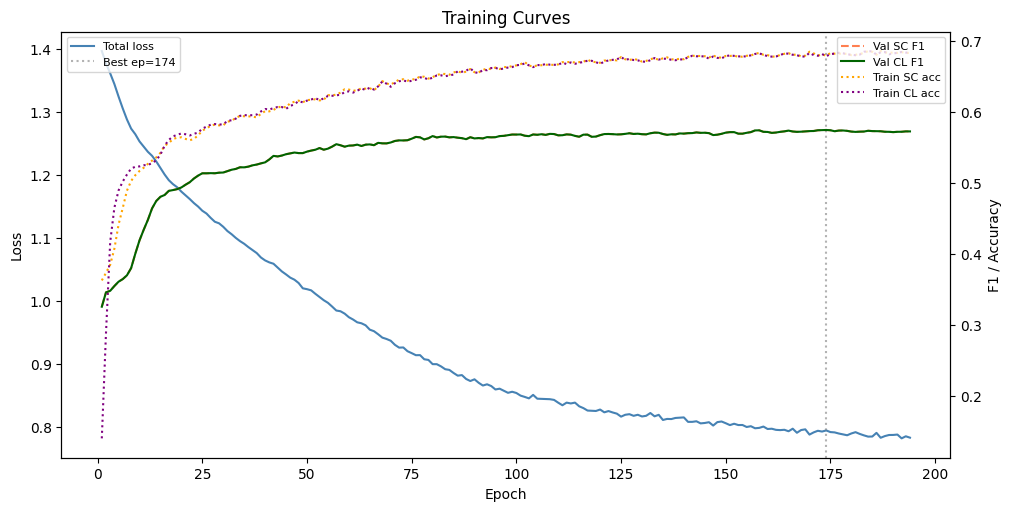

Saved: results\hierarchical_4class_t50_e20_training_curves.png
Saved: results\hierarchical_4class_t50_e20_training_history.csv


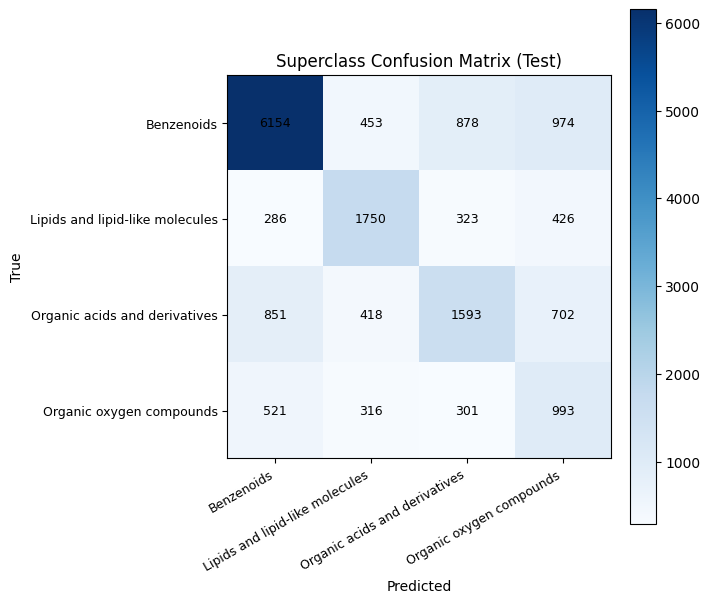

Saved: results\hierarchical_4class_t50_e20_superclass_confusion.png


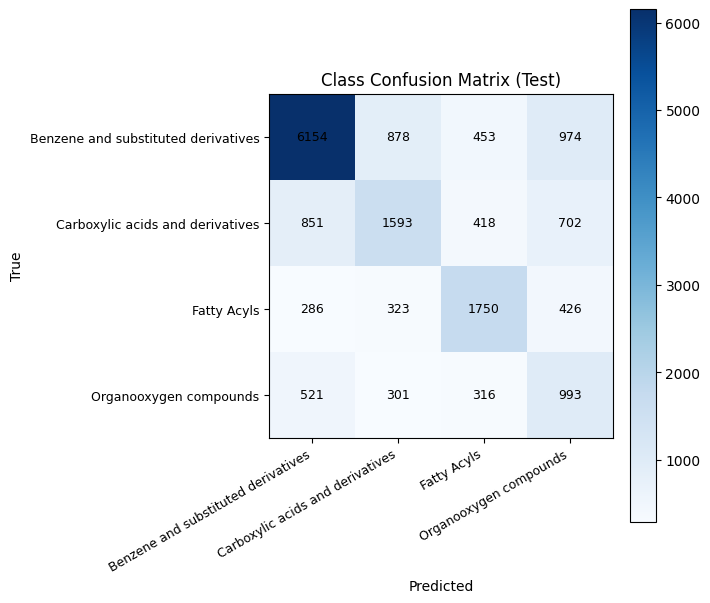

Saved: results\hierarchical_4class_t50_e20_class_confusion.png
Saved: results\hierarchical_4class_t50_e20_confusion_matrices_superclass.csv
Saved: results\hierarchical_4class_t50_e20_confusion_matrices_class.csv


In [25]:
# Figure 1: Training curves
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ep = range(1, len(history['loss']) + 1)

ax.plot(ep, history['loss'], label='Total loss', color='steelblue')
ax2 = ax.twinx()
ax2.plot(ep, history['val_sc_f1'], label='Val SC F1', color='coral',     linestyle='--')
ax2.plot(ep, history['val_cl_f1'], label='Val CL F1', color='darkgreen', linestyle='-')
ax2.plot(ep, history['tr_sc_acc'], label='Train SC acc', color='orange',  linestyle=':')
ax2.plot(ep, history['tr_cl_acc'], label='Train CL acc', color='purple',  linestyle=':')
ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.6, label=f'Best ep={best_ep}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('F1 / Accuracy')
ax.set_title('Training Curves', fontsize=12)
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
plt.savefig(artifact_path('training_curves', 'png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {artifact_path("training_curves", "png")}')

_history_path = artifact_path('training_history', 'csv')
pd.DataFrame(history).assign(epoch=range(1, len(history['loss']) + 1)).to_csv(_history_path, index=False)
print(f'Saved: {_history_path}')


# Figure 2: Superclass confusion matrix
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
cm_sc = confusion_matrix(te_sc_t, te_sc_p)
im    = ax.imshow(cm_sc, cmap='Blues')
ax.set_xticks(range(n_sc)); ax.set_yticks(range(n_sc))
ax.set_xticklabels(le_sc.classes_, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(le_sc.classes_, fontsize=9)
for i in range(n_sc):
    for j in range(n_sc):
        ax.text(j, i, str(cm_sc[i, j]), ha='center', va='center', fontsize=9)
ax.set_title('Superclass Confusion Matrix (Test)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im, ax=ax)
plt.savefig(artifact_path('superclass_confusion', 'png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {artifact_path("superclass_confusion", "png")}')


# Figure 3: Class confusion matrix 
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
cm_cl = confusion_matrix(te_cl_t, te_cl_p)
im    = ax.imshow(cm_cl, cmap='Blues')
ax.set_xticks(range(n_cl)); ax.set_yticks(range(n_cl))
ax.set_xticklabels(le_cl.classes_, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(le_cl.classes_, fontsize=9)
for i in range(n_cl):
    for j in range(n_cl):
        ax.text(j, i, str(cm_cl[i, j]), ha='center', va='center', fontsize=9)
ax.set_title('Class Confusion Matrix (Test)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im, ax=ax)
plt.savefig(artifact_path('class_confusion', 'png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {artifact_path("class_confusion", "png")}')

_cm_sc_path = artifact_path('confusion_matrices_superclass', 'csv')
_cm_cl_path = artifact_path('confusion_matrices_class', 'csv')
pd.DataFrame(cm_sc, index=le_sc.classes_, columns=le_sc.classes_).to_csv(_cm_sc_path)
pd.DataFrame(cm_cl, index=le_cl.classes_, columns=le_cl.classes_).to_csv(_cm_cl_path)
print(f'Saved: {_cm_sc_path}')
print(f'Saved: {_cm_cl_path}')

## Inference

In [26]:
def predict_json(node_indices, top_k=5):
    """Return hierarchical top-k predictions as a JSON-serialisable list.

    Args:
        node_indices : list of global node positions (indices into node_order_indices)
        top_k        : number of top class predictions to return per node

    Returns:
        List of dicts. Each dict has:
          - node_index          : int
          - predicted_superclass: str
          - superclass_prob     : float
          - top_classes         : list of {predicted_class, probability}
    """
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(
            x_aug_dev, mcn_ei_eval_dev, mcn_ea_eval_dev, sc_to_cl_mask_dev)

    results = []
    for idx in node_indices:
        # Superclass: softmax over superclass logits
        sc_probs  = F.softmax(sc_lg[idx], dim=0)
        sc_id     = sc_probs.argmax().item()
        sc_label  = le_sc.inverse_transform([sc_id])[0]
        sc_prob   = round(sc_probs[sc_id].item(), 4)

        # Class: softmax over masked class logits
        # Invalid classes (not children of predicted superclass) have -inf logit → 0 prob
        cl_probs          = F.softmax(cl_lgm[idx], dim=0)
        topk_probs, topk_ids = cl_probs.topk(min(top_k, n_cl))

        top_classes = [
            {
                'predicted_class': le_cl.inverse_transform([cid.item()])[0],
                'probability':     round(p.item(), 4),
            }
            for cid, p in zip(topk_ids, topk_probs)
            # Skip classes that were masked (probability ≈ 0)
            if not torch.isinf(cl_lgm[idx][cid]) and p.item() > 1e-4
        ]

        results.append({
            'node_index':            idx,
            'predicted_superclass':  sc_label,
            'superclass_prob':       sc_prob,
            'top_classes':           top_classes,
        })
    return results

In [27]:
# Step 1: Parse the spectrum 
def parse_single_spectrum(filepath):
    peaks = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line in ('BEGIN IONS', 'END IONS'): continue
            if '=' in line: continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    peaks.append([float(parts[0]), float(parts[1])])
                except ValueError:
                    pass
    return np.array(peaks, dtype=float) if peaks else np.empty((0, 2), dtype=float)

filepath = r"C:\Users\bibhushaojha\Desktop\notebook_backup\188.16 spectra 1"
peaks = parse_single_spectrum(filepath)

# Step 2: Build 340-dim spectral features 
raw_feat  = peaks_to_features(peaks)
norm_feat = ((raw_feat - feat_mean[0]) / feat_std[0]).astype(np.float32)

# Step 3: Assign to nearest community centroid 
sims     = sk_cosine(norm_feat.reshape(1, -1), comm_centroids)
best_cid = sims.argmax()
dist     = float(1.0 - sims[0, best_cid])

comm_feat = np.array([
    np.log1p(comm_sizes_arr[best_cid]),
    0.0,
    dist,
    1.0,
], dtype=np.float32)

# Step 4: Build 344-dim feature tensor
x_new  = torch.tensor(
    np.concatenate([norm_feat, comm_feat]).reshape(1, -1),
    dtype=torch.float32
).to(device)
ei_new = torch.tensor([[0], [0]], dtype=torch.long).to(device)
ea_new = torch.tensor([[1.0]], dtype=torch.float32).to(device)

# Step 5: Predict (no_grad for clean probabilities)
model.eval()
with torch.no_grad():
    sc_lg, cl_lgm = model.predict(x_new, ei_new, ea_new, sc_to_cl_mask_dev)

# Step 6: Build JSON output
def build_prediction_json(sc_logits, cl_logits_masked, top_k=5):
    sc_probs = F.softmax(sc_logits[0], dim=0)
    if top_k is None:
        sc_indices = torch.argsort(sc_probs, descending=True)
    else:
        _, sc_indices = sc_probs.topk(min(top_k, n_sc))
    sc_predictions = [
        {
            "predicted_superclass": le_sc.inverse_transform([idx.item()])[0],
            "probability":          round(float(sc_probs[idx].item()), 4),
        }
        for idx in sc_indices
    ]
    cl_probs = F.softmax(cl_logits_masked[0], dim=0)
    if top_k is None:
        cl_indices = torch.argsort(cl_probs, descending=True)
    else:
        _, cl_indices = cl_probs.topk(min(top_k, n_cl))
    cl_predictions = [
        {
            "predicted_class": le_cl.inverse_transform([idx.item()])[0],
            "probability":     round(float(cl_probs[idx].item()), 4),
        }
        for idx in cl_indices
        if not torch.isinf(cl_logits_masked[0][idx])
    ]
    return {"predictions": {"superclass": sc_predictions, "class": cl_predictions}}

# Step 7: Sort predictions for display
sc_probs = F.softmax(sc_lg[0], dim=0)
cl_probs = F.softmax(cl_lgm[0], dim=0)

sc_sorted = sorted(
    [(le_sc.inverse_transform([i])[0], float(sc_probs[i])) for i in range(n_sc)],
    key=lambda x: x[1], reverse=True
)
cl_sorted = sorted(
    [(le_cl.inverse_transform([i])[0], float(cl_probs[i]))
     for i in range(n_cl)
     if not torch.isinf(cl_lgm[0][i])],
    key=lambda x: x[1], reverse=True
)

print('=' * 55)
print('  SPECTRUM CLASSIFICATION RESULT')
print('=' * 55)
print(f'  Spectrum     : 188.16 spectra 1')
print(f'  Precursor m/z: 188.1643')
print(f'  Peaks        : {len(peaks)}')
print('-' * 55)
print('\n  SUPERCLASS PREDICTIONS:')
for rank, (name, prob) in enumerate(sc_sorted, 1):
    bar = '█' * int(prob * 20)
    print(f'  {rank}. {name:<40} {prob*100:5.1f}%  {bar}')
print('\n  CLASS PREDICTIONS:')
for rank, (name, prob) in enumerate(cl_sorted, 1):
    bar = '█' * int(prob * 20)
    print(f'  {rank}. {name:<40} {prob*100:5.1f}%  {bar}')
print('\n  FINAL ANSWER:')
print(f'  Superclass → {sc_sorted[0][0]}')
print(f'  Class      → {cl_sorted[0][0]}')
print('=' * 55)

# Step 8: Explainability — gradient-based peak attribution  
# Separate forward pass with gradients
p_sorted = peaks.astype(np.float32)
p_sorted = p_sorted[np.argsort(p_sorted[:, 1])[::-1]][:20]

x_grad = x_new.clone().detach().requires_grad_(True)
model.eval()
sc_out, cl_out = model(x_grad, ei_new, ea_new)

pred_cl_idx = int(le_cl.transform([cl_sorted[0][0]])[0])
pred_sc_idx = int(le_sc.transform([sc_sorted[0][0]])[0])
cl_out[0, pred_cl_idx].backward()

grads = x_grad.grad[0].cpu().numpy()   # (344,)

# Peak importance: reshape spectral gradients (20 peaks × 17 features)
spec_grads      = grads[:340].reshape(20, 17)
peak_importance = np.abs(spec_grads).sum(axis=1)
peak_importance_norm = peak_importance / peak_importance.max()

# Community feature importance
comm_grads = np.abs(grads[340:])   # (4,)
comm_names = ['log_size', 'degree_centrality', 'dist_to_centroid', 'singleton_flag']

print('=' * 60)
print('  EXPLAINABILITY — WHAT DROVE THIS PREDICTION?')
print(f'  Predicted class: {cl_sorted[0][0]}')
print('=' * 60)
print('\n  TOP CONTRIBUTING PEAKS (m/z → influence on prediction):')
print(f'  {"Rank":<5} {"m/z":>8}  {"Intensity":>12}  {"Influence":>10}  Bar')
print('  ' + '-' * 55)

peak_rank = np.argsort(peak_importance_norm)[::-1]
for rank, pi in enumerate(peak_rank[:10], 1):
    if pi < len(p_sorted) and p_sorted[pi][0] > 0:
        mz        = p_sorted[pi][0]
        intensity = p_sorted[pi][1]
        imp       = peak_importance_norm[pi]
        bar       = '█' * int(imp * 20)
        print(f'  {rank:<5} {mz:>8.4f}  {intensity:>12.0f}  {imp:>10.3f}  {bar}')

print('\n  COMMUNITY STRUCTURE INFLUENCE:')
comm_norm = comm_grads / (comm_grads.max() + 1e-8)
for name, val in zip(comm_names, comm_norm):
    bar = '█' * int(val * 20)
    print(f'  {name:<25} {val:.3f}  {bar}')

print('\n EXPLANATION:')
top_peak_idx = peak_rank[0]
if top_peak_idx < len(p_sorted):
    top_mz  = p_sorted[top_peak_idx][0]
    top_int = p_sorted[top_peak_idx][1]
    print(f'  The model predicted "{cl_sorted[0][0]}" mainly because:')
    print(f'  • The fragment at m/z {top_mz:.2f} was the strongest signal')
    print(f'    (intensity {top_int:.0f}) — this peak had the highest influence')
    if len(peak_rank) > 1:
        second_mz = p_sorted[peak_rank[1]][0]
        print(f'  • The fragment at m/z {second_mz:.2f} was the second most influential')
    print(f'  • The spectrum was assigned to a community of')
    print(f'    {int(comm_sizes_arr[best_cid])} similar spectra (dist={dist:.3f} from center)')
    if dist > 0.5:
        print(f'  • Note: this spectrum sits far from its community center')
        print(f'    (dist={dist:.3f}) — prediction confidence may be lower')
print('=' * 60)

  SPECTRUM CLASSIFICATION RESULT
  Spectrum     : 188.16 spectra 1
  Precursor m/z: 188.1643
  Peaks        : 15
-------------------------------------------------------

  SUPERCLASS PREDICTIONS:
  1. Lipids and lipid-like molecules           99.8%  ███████████████████
  2. Benzenoids                                 0.1%  
  3. Organic acids and derivatives              0.0%  
  4. Organic oxygen compounds                   0.0%  

  CLASS PREDICTIONS:
  1. Fatty Acyls                              100.0%  ████████████████████

  FINAL ANSWER:
  Superclass → Lipids and lipid-like molecules
  Class      → Fatty Acyls
  EXPLAINABILITY — WHAT DROVE THIS PREDICTION?
  Predicted class: Fatty Acyls

  TOP CONTRIBUTING PEAKS (m/z → influence on prediction):
  Rank       m/z     Intensity   Influence  Bar
  -------------------------------------------------------
  1     188.1643      15753935       1.000  ████████████████████
  2      73.0291       2240180       0.946  ██████████████████
  3   